# 2024/12/19更新
- 書籍発売後にライブラリのバージョンアップが生じたため、書籍のコードが一部動作しなくなりました
- このため、書籍のコードが動作するようにコードを一部変更
    - 変更を最小化するため、基本的には書籍に合わせてライブラリをダウングレード
    - 名称変更となったライブラリは最新のライブラリ名に変更

In [1]:
# 引数が大きく変更されているため、ダウングレードで対応
# 最初に実行してください。
# !pip install pandas==1.3.5
# !pip install lightgbm==3.3.1
# !pip install scikit-learn==1.0.2
# !pip install numba==0.58.0  # 2024/12/19追加

# なお、LightGBMの最新版ではCallbackが使われており、過去バージョンと大きく書き方が変化。最新版を使い方を知りたい場合は公式ページを参照してください。
# https://lightgbm.readthedocs.io/en/latest/index.html

In [2]:
# 2024/12/19追加
# ここで一度再起動してください。下記の２つのいずれかを実行。 
#   - 方法1: 下記コードを実行するとメッセージボックスが表示されるので、「OK」ボタンを押す
#   - 方法2: メニューの「Run」から「Restart & clear cel outputs」を選択して再起動

# import IPython
# IPython.Application.instance().kernel.do_shutdown(restart=True)

# Kaggleで磨く 機械学習の実践力
# 第5章 特徴量エンジニアリング

# 5.1 特徴量エンジニアリングの進め方
#### スクリプト: ライブラリのインポート (スクリプト4-1の再掲)

In [4]:
import numpy as np
import pandas as pd
import os
import importlib

# 可視化
import matplotlib.pyplot as plt

# 前処理
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# バリデーション
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold

# 評価指標
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# モデリング: lightgbm
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

import unidic_lite

%matplotlib inline

ModuleNotFoundError: No module named 'unidic_lite'

#### スクリプト: ファイルの読み込み (スクリプト4-2の再掲)

In [ ]:
df_train = pd.read_csv(os.path.join("..", "Datasets", "Titanic", "train.csv"))

#### スクリプト: データセット作成 (スクリプト4-8の再掲)

In [ ]:
x_train, y_train, id_train = df_train[["Pclass", "Fare"]], \
                             df_train[["Survived"]], \
                             df_train[["PassengerId"]]
print(x_train.shape, y_train.shape, id_train.shape)

(891, 2) (891, 1) (891, 1)


#### スクリプト5-1: モデル学習・評価 (スクリプト4-15を関数化)

In [ ]:
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary', 
    'metric': 'auc',
    'learning_rate': 0.1,
    'num_leaves': 16,
    'n_estimators': 100000,
    "random_state": 123,
    "importance_type": "gain",
}    

def train_cv(input_x,
             input_y,
             input_id,
             params,
             n_splits=5,
            ):
    metrics = []
    imp = pd.DataFrame()

    cv = list(StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123).split(input_x, input_y))
    for nfold in np.arange(n_splits):
        print("-"*20, nfold, "-"*20)
        idx_tr, idx_va = cv[nfold][0], cv[nfold][1]
        x_tr, y_tr = input_x.loc[idx_tr, :], input_y.loc[idx_tr, :]
        x_va, y_va = input_x.loc[idx_va, :], input_y.loc[idx_va, :]
        print(x_tr.shape, y_tr.shape)
        print(x_va.shape, y_va.shape)
        print("y_train:{:.3f}, y_tr:{:.3f}, y_va:{:.3f}".format(
            input_y["Survived"].mean(),
            y_tr["Survived"].mean(),
            y_va["Survived"].mean(),
        ))

        model = lgb.LGBMClassifier(**params)
#         model.fit(x_tr,
#                   y_tr,
#                   eval_set=[(x_tr,y_tr), (x_va,y_va)],
#                   early_stopping_rounds=100,
#                   verbose=100,
#                  )
        
        # 2024/02/14環境で動かしたい場合はこのコードを利用してください。
        model.fit(x_tr,
                  y_tr,
                  eval_set=[(x_tr,y_tr), (x_va,y_va)],
                  callbacks=[
                      lgb.early_stopping(stopping_rounds=100, verbose=True),
                      lgb.log_evaluation(100),
                  ],
                 )

        y_tr_pred = model.predict(x_tr)
        y_va_pred = model.predict(x_va)
        metric_tr = accuracy_score(y_tr, y_tr_pred)
        metric_va = accuracy_score(y_va, y_va_pred)
        print("[accuracy] tr: {:.2f}, va: {:.2f}".format(metric_tr, metric_va))    
        metrics.append([nfold, metric_tr, metric_va])

        _imp = pd.DataFrame({"col":input_x.columns, "imp":model.feature_importances_, "nfold":nfold})
        imp = pd.concat([imp, _imp], axis=0, ignore_index=True)

    print("-"*20, "result", "-"*20)
    metrics = np.array(metrics)
    print(metrics)

    print("[cv ] tr: {:.2f}+-{:.2f}, va: {:.2f}+-{:.2f}".format(
        metrics[:,1].mean(), metrics[:,1].std(),
        metrics[:,2].mean(), metrics[:,2].std(),
    ))

    imp = imp.groupby("col")["imp"].agg(["mean", "std"])
    imp.columns = ["imp", "imp_std"]
    imp = imp.reset_index(drop=False)

    print("Done.")
    
    return imp, metrics

#### スクリプト5-2: モデル学習・評価

In [ ]:
imp, metrics = train_cv(x_train, y_train, id_train, params, n_splits=5)

-------------------- 0 --------------------
(712, 2) (712, 1)
(179, 2) (179, 1)
y_train:0.384, y_tr:0.383, y_va:0.385
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 123
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.844961	valid_1's auc: 0.716469
Early stopping, best iteration is:
[12]	training's auc: 0.793779	valid_1's auc: 0.740382
[accuracy] tr: 0.72, va: 0.68
-------------------- 1 --------------------
(713, 2) (713, 1)
(178, 2) (178, 1)
y_train:0.384, y_tr:0.384, y_va:0.382
[LightGBM] [Info] Number of positive: 274,

Early stopping, best iteration is:
[26]	training's auc: 0.807006	valid_1's auc: 0.757219
[accuracy] tr: 0.75, va: 0.68
-------------------- 2 --------------------
(713, 2) (713, 1)
(178, 2) (178, 1)
y_train:0.384, y_tr:0.384, y_va:0.382
[LightGBM] [Info] Number of positive: 274, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 128
[LightGBM] [Info] Number of data points in the train set: 713, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.384292 -> initscore=-0.471371
[LightGBM] [Info] Start training from score -0.471371
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.839483	valid_1's auc: 0.732687
[200]	training's auc: 0.849542	valid_1's auc: 0.737233
Early stopping, best iteration is:
[191]	training's auc: 0.849143	valid_1's auc: 0.739906
[accuracy] tr: 

#### スクリプト5-3: 変数追加・データセット作成（Ageの追加）

In [ ]:
x_train, y_train, id_train = df_train[["Pclass", "Fare", "Age"]], \
                             df_train[["Survived"]], \
                             df_train[["PassengerId"]]
print(x_train.shape, y_train.shape, id_train.shape)

(891, 3) (891, 1) (891, 1)


#### スクリプト5-4: モデル学習・評価（新しいデータセットの利用）

In [ ]:
imp, metrics = train_cv(x_train, y_train, id_train, params, n_splits=5)

-------------------- 0 --------------------
(712, 3) (712, 1)
(179, 3) (179, 1)
y_train:0.384, y_tr:0.383, y_va:0.385
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 185
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.931588	valid_1's auc: 0.721937
Early stopping, best iteration is:
[69]	training's auc: 0.913235	valid_1's auc: 0.72892
[accuracy] tr: 0.82, va: 0.70
-------------------- 1 --------------------
(713, 3) (713, 1)
(178, 3) (178, 1)
y_train:0.384, y_tr:0.384, y_va:0.382
[LightGBM] [Info] Number of positive: 274, 

#### スクリプト5-5: 説明変数の重要度の算出

In [ ]:
imp.sort_values("imp", ascending=False, ignore_index=True)

,col,imp,imp_std
0,Fare,547.621958,270.958097
1,Age,436.497719,247.807858
2,Pclass,299.843845,103.344422


# 5.2 データ前処理

## 5.2.1 データの確認（詳細）
#### スクリプト5-6: 要約統計量の一括確認 (数値データ)

In [ ]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


#### スクリプト5-7: 要約統計量の一括確認（カテゴリ変数）

In [ ]:
df_train.describe(exclude='number').T

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


#### 要約統計量の一括確認（両方まとめて）

In [ ]:
df_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


#### スクリプト5-8: 要約統計量の確認 (数値データ)

In [ ]:
df_train[["Fare"]].agg(["mean"]).T

,mean
Fare,32.204208


#### スクリプト5-9 複数の要約統計量の確認（その1）

In [ ]:
df_train[["Fare"]].agg(["mean", "std", "min", "max"]).T

,mean,std,min,max
Fare,32.204208,49.693429,0.0,512.3292


#### スクリプト5-10: 複数の要約統計量の確認（その2）

In [ ]:
df_train[["Fare"]].agg(["dtype", "count", "nunique", "mean", "std", "min", "max"]).T

,dtype,count,nunique,mean,std,min,max
Fare,float64,891,248,32.204208,49.693429,0.0,512.3292


#### スクリプト5-11: 複数のカラムを同時に確認

In [ ]:
summary = df_train.describe(include="all").T
summary.insert(0, "dtype", df_train.dtypes.astype(str))
summary.insert(2, "nunique", df_train.nunique(dropna=True))
summary

,dtype,count,nunique,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,int64,891.0,891,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,int64,891.0,2,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,int64,891.0,3,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,str,891,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,str,891,2,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,float64,714.0,88,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,int64,891.0,7,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,int64,891.0,7,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,str,891,681,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,float64,891.0,248,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


#### スクリプト5-12: 種類ごとの件数確認

In [ ]:
df_train["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

#### スクリプト5-13: pandas_profilingライブラリの利用

In [ ]:
df_train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 5.2.2 欠損値の把握・補間
#### スクリプト5-14: 欠損値の確認

In [ ]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### スクリプト5-15: 欠損値補間（0埋め）

In [ ]:
df_train["Age_fillna_0"] = df_train["Age"].fillna(0)
df_train.loc[df_train["Age"].isnull(), ["Age", "Age_fillna_0"]].head()

,Age,Age_fillna_0
5,NaN,0.0
17,NaN,0.0
19,NaN,0.0
26,NaN,0.0
28,NaN,0.0


#### スクリプト5-16: 欠損値補間（平均値補間）

In [ ]:
df_train["Age_fillna_mean"] = df_train["Age"].fillna(df_train["Age"].mean())
df_train.loc[df_train["Age"].isnull(), ["Age", "Age_fillna_mean"]].head()

,Age,Age_fillna_mean
5,NaN,29.699118
17,NaN,29.699118
19,NaN,29.699118
26,NaN,29.699118
28,NaN,29.699118


#### スクリプト5-17: 欠損値補間（空白埋め）

In [ ]:
df_train["Cabin_fillna_space"] = df_train["Cabin"].fillna("")
df_train.loc[df_train["Cabin"].isnull(), ["Cabin", "Cabin_fillna_space"]].head()

,Cabin,Cabin_fillna_space
0,NaN,
2,NaN,
4,NaN,
5,NaN,
7,NaN,


#### スクリプト5-18: 欠損値補間（最頻値補間）

In [ ]:
df_train["Cabin_fillna_mode"] = df_train["Cabin"].fillna(df_train["Cabin"].mode()[0])
df_train.loc[df_train["Cabin"].isnull(), ["Cabin", "Cabin_fillna_mode"]].head()

,Cabin,Cabin_fillna_mode
0,NaN,B96 B98
2,NaN,B96 B98
4,NaN,B96 B98
5,NaN,B96 B98
7,NaN,B96 B98


## 5.2.3 外れ値の検出・補正
#### スクリプト5-19: 最小値と最大値の確認

In [ ]:
df_train["Age"].agg(["min","max"])

min     0.42
max    80.00
Name: Age, dtype: float64

#### スクリプト5-20: 分布の確認

<Axes: >

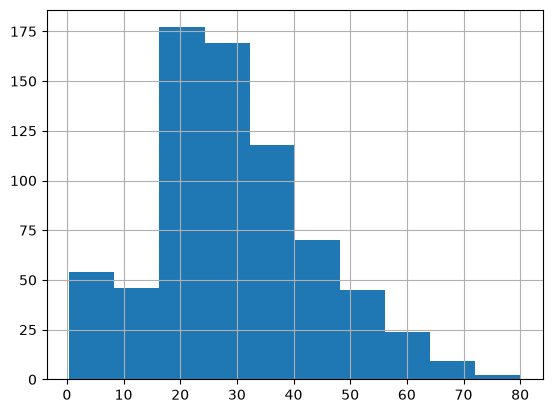

In [ ]:
df_train["Age"].hist()

#### スクリプト5-21: 四分位範囲を利用した外れ値検出方法

In [ ]:
quartile = df_train["Age"].quantile(q=0.75) - df_train["Age"].quantile(q=0.25)
print("四分位範囲:", quartile)
print("下限値:", df_train["Age"].quantile(q=0.25) - quartile*1.5)
print("上限値:", df_train["Age"].quantile(q=0.75) + quartile*1.5)

四分位範囲: 17.875
下限値: -6.6875
上限値: 64.8125


#### スクリプト5-22: 外れ値を欠損値に変換

In [ ]:
df_train.loc[df_train["Age"]<0, "Age"] = np.nan 

## 5.2.4 標準化・正規化
#### スクリプト5-23: 標準化

In [ ]:
value_mean = df_train["Fare"].mean()
value_std = df_train["Fare"].std(ddof=0) #母集団の標準偏差を利用する場合
# value_std = df_train["Fare"].std() #標本の標準偏差を利用する場合
print("mean:", value_mean, ", std:", value_std)

df_train["Fare_standard"] = (df_train["Fare"] - value_mean) / value_std
df_train[["Fare", "Fare_standard"]].head()

mean: 32.204207968574636 , std: 49.6655344447741


,Fare,Fare_standard
0,7.2500,-0.502445
1,71.2833,0.786845
2,7.9250,-0.488854
3,53.1000,0.420730
4,8.0500,-0.486337


#### スクリプト5-24: 標準化（scikit-learn利用）

In [ ]:
std = StandardScaler()
std.fit(df_train[["Fare"]])
print("mean:", std.mean_[0], ", std:", np.sqrt(std.var_[0]))

df_train["Fare_standard"] = std.transform(df_train[["Fare"]])
df_train[["Fare", "Fare_standard"]].head()

mean: 32.204207968574636 , std: 49.6655344447741


,Fare,Fare_standard
0,7.2500,-0.502445
1,71.2833,0.786845
2,7.9250,-0.488854
3,53.1000,0.420730
4,8.0500,-0.486337


#### スクリプト5-25: 正規化

In [ ]:
value_min = df_train["Fare"].min()
value_max = df_train["Fare"].max()
print("min:", value_min, ", max:", value_max)

df_train["Fare_normalize"] = (df_train["Fare"] - value_min) / (value_max - value_min)
df_train[["Fare", "Fare_normalize"]].head()

min: 0.0 , max: 512.3292


,Fare,Fare_normalize
0,7.2500,0.014151
1,71.2833,0.139136
2,7.9250,0.015469
3,53.1000,0.103644
4,8.0500,0.015713


#### スクリプト5-26: 正規化（scikit-learn利用）

In [ ]:
mms = MinMaxScaler(feature_range=(0, 1)) #範囲を変更
mms.fit(df_train[["Fare"]])
print("min:", mms.data_min_[0], ", max:", mms.data_max_[0])

df_train["Fare_normalize"] = mms.transform(df_train[["Fare"]])
df_train[["Fare", "Fare_normalize"]].head()

min: 0.0 , max: 512.3292


,Fare,Fare_normalize
0,7.2500,0.014151
1,71.2833,0.139136
2,7.9250,0.015469
3,53.1000,0.103644
4,8.0500,0.015713


# 5.3 特徴量生成
## 5.3.1 単変数: 数値
#### スクリプト5-27: 対数変換

In [ ]:
df_train["Fare_log"] = np.log(df_train["Fare"] + 1e-5)
df_train[["Fare", "Fare_log"]].head()

,Fare,Fare_log
0,7.2500,1.981003
1,71.2833,4.266662
2,7.9250,2.070024
3,53.1000,3.972177
4,8.0500,2.085673


#### スクリプト5-28: 累乗／指数関数／逆数

In [ ]:
df_train["Fare_square"] = df_train["Fare"].apply(lambda x: x**2)
df_train["Fare_exp"] = df_train["Fare"].apply(lambda x: np.exp(x))
df_train["Fare_reciprocal"] = df_train["Fare"].apply(lambda x: 1/(x+1e-3))
df_train[["Fare", "Fare_square", "Fare_exp", "Fare_reciprocal"]].head()

,Fare,Fare_square,Fare_exp,Fare_reciprocal
0,7.2500,52.562500,1.408105e+03,0.137912
1,71.2833,5081.308859,9.077031e+30,0.014028
2,7.9250,62.805625,2.765564e+03,0.126167
3,53.1000,2819.610000,1.150898e+23,0.018832
4,8.0500,64.802500,3.133795e+03,0.124208


#### スクリプト5-29: 離散化

In [ ]:
df_train["Age_bin"] = pd.cut(df_train["Age"], 
                             bins=[0,10,20,30,40,50,100],
                             right=False,
                             labels=["10代未満","10代","20代","30代","40代","50代以上"],
                             duplicates="raise",
                             include_lowest=True,
                            )
df_train["Age_bin"] = df_train["Age_bin"].astype(str)
df_train[["Age", "Age_bin"]].head()

,Age,Age_bin
0,22.0,20代
1,38.0,30代
2,26.0,20代
3,35.0,30代
4,35.0,30代


#### スクリプト5-30: 欠損かどうかで0/1に変換

In [ ]:
df_train["Age_na"] = df_train["Age"].isnull()*1
df_train[["Age", "Age_na"]].head(7)

,Age,Age_na
0,22.0,0
1,38.0,0
2,26.0,0
3,35.0,0
4,35.0,0
5,NaN,1
6,54.0,0


## 5.3.2 単変数：カテゴリ変数
#### スクリプト5-31: one-hot-encoding

In [ ]:
ohe_embarked = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_embarked.fit(df_train[["Embarked"]])

tmp_embarked = pd.DataFrame(
    ohe_embarked.transform(df_train[["Embarked"]]),
    columns=["Embarked_{}".format(i) for i in ohe_embarked.categories_[0]],
)

df_train = pd.concat([df_train, tmp_embarked], axis=1)
df_train[["Embarked", "Embarked_C", "Embarked_Q", "Embarked_S", "Embarked_nan"]].head()

,Embarked,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,S,0.0,0.0,1.0,0.0
1,C,1.0,0.0,0.0,0.0
2,S,0.0,0.0,1.0,0.0
3,S,0.0,0.0,1.0,0.0
4,S,0.0,0.0,1.0,0.0


#### スクリプト5-32: one-hot-encoding（一括変換）

In [ ]:
df_ohe = pd.get_dummies(df_train[["Embarked", "Sex"]], dummy_na=True, drop_first=False)
df_ohe.head()

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Sex_female,Sex_male,Sex_nan
0,False,False,True,False,False,True,False
1,True,False,False,False,True,False,False
2,False,False,True,False,True,False,False
3,False,False,True,False,True,False,False
4,False,False,True,False,False,True,False


#### スクリプト5-33: count-encoding

In [ ]:
ce_Embarked = df_train["Embarked"].value_counts().to_dict()
print(ce_Embarked)
df_train["Embarked_ce"] = df_train["Embarked"].map(ce_Embarked)
df_train[["Embarked", "Embarked_ce"]].head()

{'S': 644, 'C': 168, 'Q': 77}


,Embarked,Embarked_ce
0,S,644.0
1,C,168.0
2,S,644.0
3,S,644.0
4,S,644.0


#### スクリプト5-34: label-encoding

In [ ]:
le_embarked = LabelEncoder()
le_embarked.fit(df_train["Embarked"])
df_train["Embarked_le"] = le_embarked.transform(df_train["Embarked"])
df_train[["Embarked", "Embarked_le"]].head(5)

,Embarked,Embarked_le
0,S,2
1,C,0
2,S,2
3,S,2
4,S,2


#### スクリプト5-35: 欠損かどうかで0/1に変換

In [ ]:
df_train["Embarked_na"] = df_train["Embarked"].isnull()*1
df_train.loc[df_train["Embarked"].isnull(), ["Embarked", "Embarked_na"]].head(5)

,Embarked,Embarked_na
61,NaN,1
829,NaN,1


## 5.3.3 2変数組合せ: 数値x数値
#### スクリプト5-36: 数値x数値

In [ ]:
df_train["SibSp_+_Parch"] = df_train["SibSp"] + df_train["Parch"]
df_train[["SibSp", "Parch", "SibSp_+_Parch"]].head()

,SibSp,Parch,SibSp_+_Parch
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


## 5.3.4 2変数組合せ: 数値xカテゴリ変数
#### スクリプト5-37: 数値xカテゴリ変数（例1）

In [ ]:
df_agg = df_train.groupby("Sex")["Fare"].agg(["mean"]).reset_index()
df_agg.columns = ["Sex", "mean_Fare_by_Sex"]
print("集約テーブル")
display(df_agg)

df_train = pd.merge(df_train, df_agg, on="Sex", how="left")
print("結合後テーブル")
display(df_train[["Sex", "Fare", "mean_Fare_by_Sex"]].head())

集約テーブル


,Sex,mean_Fare_by_Sex
0,female,44.479818
1,male,25.523893


結合後テーブル


,Sex,Fare,mean_Fare_by_Sex
0,male,7.2500,25.523893
1,female,71.2833,44.479818
2,female,7.9250,44.479818
3,female,53.1000,44.479818
4,male,8.0500,25.523893


#### スクリプト5-38: 数値xカテゴリ変数（例2）

In [ ]:
df_train["mean_Fare_by_Sex"] = df_train.groupby("Sex")["Fare"].transform("mean")
df_train[["Sex", "Fare", "mean_Fare_by_Sex"]].head()

,Sex,Fare,mean_Fare_by_Sex
0,male,7.2500,25.523893
1,female,71.2833,44.479818
2,female,7.9250,44.479818
3,female,53.1000,44.479818
4,male,8.0500,25.523893


## 5.3.5 2変数組合せ: カテゴリ変数xカテゴリ変数
#### スクリプト5-39: ①カテゴリ変数xカテゴリ変数：出現回数（例1）

In [ ]:
df_tbl = pd.crosstab(df_train["Sex"], df_train["Embarked"])
print("集約テーブル（クロス集計）")
display(df_tbl)

df_tbl = df_tbl.reset_index()
df_tbl = pd.melt(df_tbl, id_vars="Sex", value_name="count_Sex_x_Embarked")
print("集約テーブル（縦持ち変換後）")
display(df_tbl)

df_train = pd.merge(df_train, df_tbl, on=["Sex", "Embarked"], how="left")
print("結合後テーブル")
df_train[["Sex", "Embarked", "count_Sex_x_Embarked"]].head()

集約テーブル（クロス集計）


Embarked,C,Q,S
Sex,,,
female,73,36,203
male,95,41,441


集約テーブル（縦持ち変換後）


,Sex,Embarked,count_Sex_x_Embarked
0,female,C,73
1,male,C,95
2,female,Q,36
3,male,Q,41
4,female,S,203
5,male,S,441


結合後テーブル


,Sex,Embarked,count_Sex_x_Embarked
0,male,S,441.0
1,female,C,73.0
2,female,S,203.0
3,female,S,203.0
4,male,S,441.0


#### スクリプト5-40: ①カテゴリ変数xカテゴリ変数：出現回数（例2）

In [ ]:
df_train["count_Sex_x_Embarked"] = df_train.groupby(["Sex", "Embarked"])["PassengerId"].transform("count")
df_train[["Sex", "Embarked", "count_Sex_x_Embarked"]].head()

,Sex,Embarked,count_Sex_x_Embarked
0,male,S,441.0
1,female,C,73.0
2,female,S,203.0
3,female,S,203.0
4,male,S,441.0


#### スクリプト5-41: ②カテゴリ変数xカテゴリ変数：出現割合

In [ ]:
df_tbl = pd.crosstab(df_train["Sex"], df_train["Embarked"], normalize="index")
print("集約テーブル（行方向の和で割る）")
display(df_tbl)

df_tbl = df_tbl.reset_index()
df_tbl = pd.melt(df_tbl, id_vars="Sex", value_name="rate_Sex_x_Embarked")
print("集約テーブル（縦持ち変換後）")
display(df_tbl)

df_train = pd.merge(df_train, df_tbl, on=["Sex", "Embarked"], how="left")
print("結合後テーブル")
df_train[["Sex", "Embarked", "rate_Sex_x_Embarked"]].head()

集約テーブル（行方向の和で割る）


Embarked,C,Q,S
Sex,,,
female,0.233974,0.115385,0.650641
male,0.164645,0.071057,0.764298


集約テーブル（縦持ち変換後）


,Sex,Embarked,rate_Sex_x_Embarked
0,female,C,0.233974
1,male,C,0.164645
2,female,Q,0.115385
3,male,Q,0.071057
4,female,S,0.650641
5,male,S,0.764298


結合後テーブル


,Sex,Embarked,rate_Sex_x_Embarked
0,male,S,0.764298
1,female,C,0.233974
2,female,S,0.650641
3,female,S,0.650641
4,male,S,0.764298


#### スクリプト5-42: ③カテゴリ変数xカテゴリ変数：条件式を用いた変換

In [ ]:
df_train["Sex=male_&_Embarked=S"] = np.where((df_train["Sex"]=="male") & (df_train["Embarked"]=="S"), 1, 0)
df_train[["Sex", "Embarked", "Sex=male_&_Embarked=S"]].head()

,Sex,Embarked,Sex=male_&_Embarked=S
0,male,S,1
1,female,C,0
2,female,S,0
3,female,S,0
4,male,S,1


## 5.3.6 時系列データ
#### スクリプト5-43: ラグ特徴量（1行シフト）

In [ ]:
df1 = pd.DataFrame({"date":pd.date_range("2021-01-01","2021-01-10"),
                    "weather":["晴れ","晴れ","雨","くもり","くもり","晴れ","雨","晴れ","晴れ","晴れ"],
                   })

df1["weathre_shift1"] = df1["weather"].shift(1)
df1

,date,weather,weathre_shift1
0,2021-01-01,晴れ,NaN
1,2021-01-02,晴れ,晴れ
2,2021-01-03,雨,晴れ
3,2021-01-04,くもり,雨
4,2021-01-05,くもり,くもり
5,2021-01-06,晴れ,くもり
6,2021-01-07,雨,晴れ
7,2021-01-08,晴れ,雨
8,2021-01-09,晴れ,晴れ
9,2021-01-10,晴れ,晴れ


#### スクリプト5-44: ラグ特徴量（1行シフト）: シフトによって生じた欠損値を補間

In [ ]:
# 欠損値を前埋めしたい場合
df1["weathre_shift1"] = df1["weathre_shift1"].bfill()
df1

,date,weather,weathre_shift1
0,2021-01-01,晴れ,晴れ
1,2021-01-02,晴れ,晴れ
2,2021-01-03,雨,晴れ
3,2021-01-04,くもり,雨
4,2021-01-05,くもり,くもり
5,2021-01-06,晴れ,くもり
6,2021-01-07,雨,晴れ
7,2021-01-08,晴れ,雨
8,2021-01-09,晴れ,晴れ
9,2021-01-10,晴れ,晴れ


#### スクリプト5-45: ラグ特徴量（IDごとにシフト）

In [ ]:
df2 = pd.DataFrame({"id":["A"]*3 + ["B"]*2 + ["C"]*4,
                    "date":["2021-04-02","2021-04-10","2021-04-25",
                            "2021-04-18","2021-04-19",
                            "2021-04-01","2021-04-04","2021-04-09","2021-04-12",
                           ],
                    "money":[1000,2000,900,4000,1800,900,1200,1100,2900],
                   })
df2["date"] = pd.to_datetime(df2["date"], format="%Y-%m-%d")

df2["money_shift1"] = df2.groupby("id")["money"].shift(1)
df2

,id,date,money,money_shift1
0,A,2021-04-02,1000,NaN
1,A,2021-04-10,2000,1000.0
2,A,2021-04-25,900,2000.0
3,B,2021-04-18,4000,NaN
4,B,2021-04-19,1800,4000.0
5,C,2021-04-01,900,NaN
6,C,2021-04-04,1200,900.0
7,C,2021-04-09,1100,1200.0
8,C,2021-04-12,2900,1100.0


#### スクリプト5-46: ラグ特徴量（経過日数）

In [ ]:
df2["date_shift1"] = df2.groupby("id")["date"].shift(1)
df2["days_elapsed"] = df2["date"] - df2["date_shift1"]
df2["days_elapsed"] = df2["days_elapsed"].dt.days
df2

,id,date,money,money_shift1,date_shift1,days_elapsed
0,A,2021-04-02,1000,NaN,NaT,NaN
1,A,2021-04-10,2000,1000.0,2021-04-02,8.0
2,A,2021-04-25,900,2000.0,2021-04-10,15.0
3,B,2021-04-18,4000,NaN,NaT,NaN
4,B,2021-04-19,1800,4000.0,2021-04-18,1.0
5,C,2021-04-01,900,NaN,NaT,NaN
6,C,2021-04-04,1200,900.0,2021-04-01,3.0
7,C,2021-04-09,1100,1200.0,2021-04-04,5.0
8,C,2021-04-12,2900,1100.0,2021-04-09,3.0


#### スクリプト5-47: ウィンドウ特徴量

In [ ]:
df3 = pd.DataFrame({"date":pd.date_range("2021-01-01","2021-01-10"),
                    "temperature":[8,10,12,11,9,10,12,7,9,10],
                   })
df3["temperature_window3"] = df3["temperature"].rolling(window=3).mean()
df3

,date,temperature,temperature_window3
0,2021-01-01,8,NaN
1,2021-01-02,10,NaN
2,2021-01-03,12,10.000000
3,2021-01-04,11,11.000000
4,2021-01-05,9,10.666667
5,2021-01-06,10,10.000000
6,2021-01-07,12,10.333333
7,2021-01-08,7,9.666667
8,2021-01-09,9,9.333333
9,2021-01-10,10,8.666667


#### スクリプト5-48: ウィンドウ特徴量（IDごと）

In [ ]:
df4 = pd.DataFrame({"id":["A"]*3 + ["B"]*2 + ["C"]*4,
                    "date":["2021-04-02","2021-04-10","2021-04-25",
                            "2021-04-18","2021-04-19",
                            "2021-04-01","2021-04-04","2021-04-09","2021-04-12",
                           ],
                    "money":[1000,2000,900,4000,1800,900,1200,1100,2900],
                   })
df4["date"] = pd.to_datetime(df4["date"], format="%Y-%m-%d")
df4["money_shift1"] = df4.groupby("id")["money"].transform(lambda x: x.rolling(window=2).mean())
df4

,id,date,money,money_shift1
0,A,2021-04-02,1000,NaN
1,A,2021-04-10,2000,1500.0
2,A,2021-04-25,900,1450.0
3,B,2021-04-18,4000,NaN
4,B,2021-04-19,1800,2900.0
5,C,2021-04-01,900,NaN
6,C,2021-04-04,1200,1050.0
7,C,2021-04-09,1100,1150.0
8,C,2021-04-12,2900,2000.0


#### スクリプト5-49: 累積特徴量

In [ ]:
df5 = pd.DataFrame({"date":pd.date_range("2021-01-01","2021-01-10"),
                    "flag_rain":[0,0,1,0,0,0,1,0,0,0],
                   })
df5["flag_rain_cumsum"] = df5["flag_rain"].cumsum()
df5

,date,flag_rain,flag_rain_cumsum
0,2021-01-01,0,0
1,2021-01-02,0,0
2,2021-01-03,1,1
3,2021-01-04,0,1
4,2021-01-05,0,1
5,2021-01-06,0,1
6,2021-01-07,1,2
7,2021-01-08,0,2
8,2021-01-09,0,2
9,2021-01-10,0,2


#### スクリプト5-50: 累積特徴量（IDごと）

In [ ]:
df6 = pd.DataFrame({"id":["A"]*3 + ["B"]*2 + ["C"]*4,
                    "date":["2021-04-02","2021-04-10","2021-04-25",
                            "2021-04-18","2021-04-19",
                            "2021-04-01","2021-04-04","2021-04-09","2021-04-12",
                           ],
                    "money":[1000,2000,900,4000,1800,900,1200,1100,2900],
                   })
df6["date"] = pd.to_datetime(df6["date"], format="%Y-%m-%d")
df6["money_cumsum"] = df6.groupby("id")["money"].cumsum()
df6

,id,date,money,money_cumsum
0,A,2021-04-02,1000,1000
1,A,2021-04-10,2000,3000
2,A,2021-04-25,900,3900
3,B,2021-04-18,4000,4000
4,B,2021-04-19,1800,5800
5,C,2021-04-01,900,900
6,C,2021-04-04,1200,2100
7,C,2021-04-09,1100,3200
8,C,2021-04-12,2900,6100


## 5.3.7 テキストデータ
#### スクリプト5-51: BoWによるベクトル化

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(min_df=20)
vec.fit(df_train["Name"])

feature_names = vec.get_feature_names_out()
df_name = pd.DataFrame(vec.transform(df_train["Name"]).toarray(), columns=feature_names)

print(df_name.shape)
df_name.head()

(891, 12)


,charles,george,henry,james,john,mary,master,miss,mr,mrs,thomas,william
0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,1,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,1,0,0,0,0,0,1,0,0,1


#### スクリプト5-52: MeCabのKaggle分析環境へのインストールとインポート

In [ ]:
import MeCab
print("MeCab is available.")

MeCab is available.


#### スクリプト5-53: BoWによるベクトル化（日本語の場合）

In [ ]:
print("サンプルデータ:")
df_text = pd.DataFrame({"text": [
    "今日は雨ですね。天気予報では明日も雨です。",
    "雨なので傘を持って行った方がいいです。",
    "天気予報によると明後日は晴れのようです。",
]})
display(df_text)

print("形態素解析+分かち書き:")
dictionary_path = unidic_lite.DICDIR.replace("\\", "/")
wakati = MeCab.Tagger("-Owakati -d {}".format(dictionary_path))
df_text["text_wakati"] = df_text["text"].apply(lambda x: wakati.parse(x).replace("\n", ""))
display(df_text)

print("BoWによるベクトル化:")
vec = CountVectorizer()
vec.fit(df_text["text_wakati"])
df_text_vec = pd.DataFrame(
    vec.transform(df_text["text_wakati"]).toarray(),
    columns=vec.get_feature_names_out(),
)
df_text_vec.head()

サンプルデータ:


,text
0,今日は雨ですね。天気予報では明日も雨です。
1,雨なので傘を持って行った方がいいです。
2,天気予報によると明後日は晴れのようです。


形態素解析+分かち書き:


,text,text_wakati
0,今日は雨ですね。天気予報では明日も雨です。,今日 は 雨 です ね 。 天気 予報 で は 明日 も 雨 です 。
1,雨なので傘を持って行った方がいいです。,雨 な の で 傘 を 持っ て 行っ た 方 が いい です 。
2,天気予報によると明後日は晴れのようです。,天気 予報 に よる と 明後日 は 晴れ の よう です 。


BoWによるベクトル化:


,いい,です,よう,よる,予報,今日,天気,持っ,明後日,明日,晴れ,行っ
0,0,2,0,0,1,1,1,0,0,1,0,0
1,1,1,0,0,0,0,0,1,0,0,0,1
2,0,1,1,1,1,0,1,0,1,0,1,0
